### Helpful resources:
* [Guide to Markdown](https://paperhive.org/help/markdown)
* [Guide to LaTeX Math symbols](http://tug.ctan.org/info/undergradmath/undergradmath.pdf)
* [Python Cheat Sheets](https://ehmatthes.github.io/pcc/cheatsheets/README.html)
* [Moving to Python from MATLAB](https://bastibe.de/2013-01-20-a-python-primer-for-matlab-users.html)

# Lab #5: Atmospheric $CO_{2}$
### Farhan Ariff bin Halis Azhan
### Collaborators
* Name
* Name

## Goal and Introduction
As the lab's title suggests, this week's lab will focus on atmosperic $CO_{2}$. $CO_{2}$ is an important element in earth's atmosphere system, as it can held heat energy from sun. Hypothetically, if $CO_{2}$ is absent, more heat energy will escape to the space, which will reduce earth's temperature from 60 degree Fahrenheit to 0 degree Fahrenheit. We are also observing this elements because it shows an increasing trend in its level. This increasing trend happened due to human's increasing need to consume fuel, which will then release $CO_{2}$. 

The goal of this lab is to observe atmoshperic $CO_{2}$'s periodic behavior using two different methods, which are harmonic analysis and Fast Fourier Transformation (FFT)

## Data
The dataset we will use for this lab is co2_mm_mlo.txt, a dataset that consisted of 
year, month, said year and month in decimal date, the average of $CO_{2}$, interpolated of $CO_{2}$,  the trend (or season correlation) and days. In the data, it was mentioned if  
the average value is -99.99, it means missing data, while if the value for  
#days is -1, it means no data for the means in month. This data was collected at Mauna Loa Observatory in Hawaii from March 1958 to February 2020. The variables in this datasets that we will focus on are the
variables "decimal date" and "interpoalted".

----

## Approach and Results
The code cell below will import the required library/module that will be needed for this lab.

In [20]:
# Import critical libraries:
# !pip install cartopy
import numpy as np
import matplotlib.pyplot as plt
# Turn on in-line plotting:
%matplotlib inline

### Question 1
First of all, we will read the file using the genfromtxt function from numpy module.

In [21]:
# read files using genfromtxt function
# we will skip the first 70 header, and only use column from third to seventh columns.
data = np.genfromtxt('./co2_mm_mlo.txt',
                     skip_header=70, usecols= (2,3,4,5,6),
                     dtype=None, encoding = 'utf-8', names=True)
# print(data)
# print(data.dtype.names)

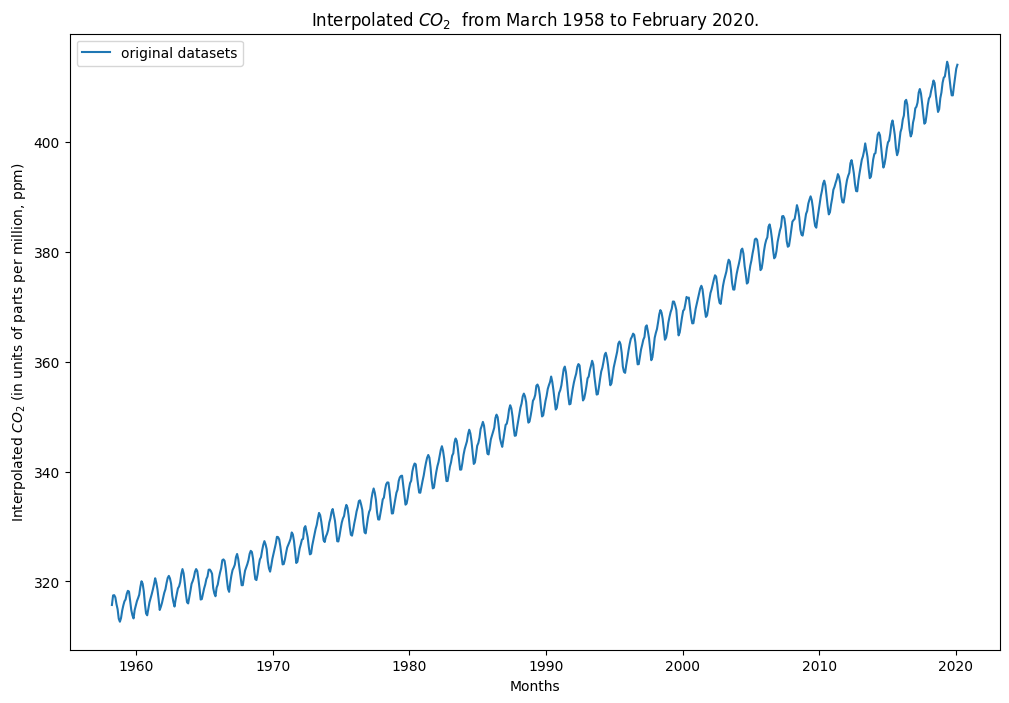

In [22]:
# Make a figure and axis variable
fig = plt.figure(figsize = (12,8))
ax = fig.subplots(1,1)

# Plot the interpolated column against decimal date
ax.plot(data['decimal'], data['interpolated'], label = 'original datasets')
#Label and title
ax.set_title(f'Interpolated $CO_{2}$  from March 1958 to February 2020.')
ax.set_ylabel(f'Interpolated $CO_{2}$ (in units of parts per million, ppm)')
ax.set_xlabel(f'Months')
ax.legend(loc='best')

From the figure above, we can figure out its qualitative trend.  
An obvious trend we can see from the figure is that $CO_{2}$ concentration in the atmospheric is increasing. There are several times it went down because of seasonal reason. For example, when it was winter, there will be less vegetation that can perform photosynthesis thus decreasing $CO_{2}$ concentration. Another reason it can went down can be due to ENSO phenomenon where increased sea temperature disturb underwater plants photosynthesis activity. Nevertheless, $CO_{2}$ concentration will increase again due to overwhelming fuel consumption over the years.

### Question 2
Secondly, we will now want to detrend the data. To detrend a data, we will subtract the polynomial fit of the data using polyfit() and polyval() function from the original data.  
The polynomial fit here can also be called trend.


In [23]:
# Now we will use polynomial to fit the interpolated data and the decimate data,
# using arbitary value for the polynomial. Here, we used value 3.
coeffs = np.polyfit(data['decimal'], data['interpolated'], 3)

In [24]:
# We then fit the coefficients array we got from polyfit function 
# using the polyval function
y_fit3 = np.polyval(coeffs, data['decimal'])
# y_fit3
# After getting the fitted array, we will need to detrend the data by subtracting the fit
# from it
detrend = data['interpolated'] - y_fit3

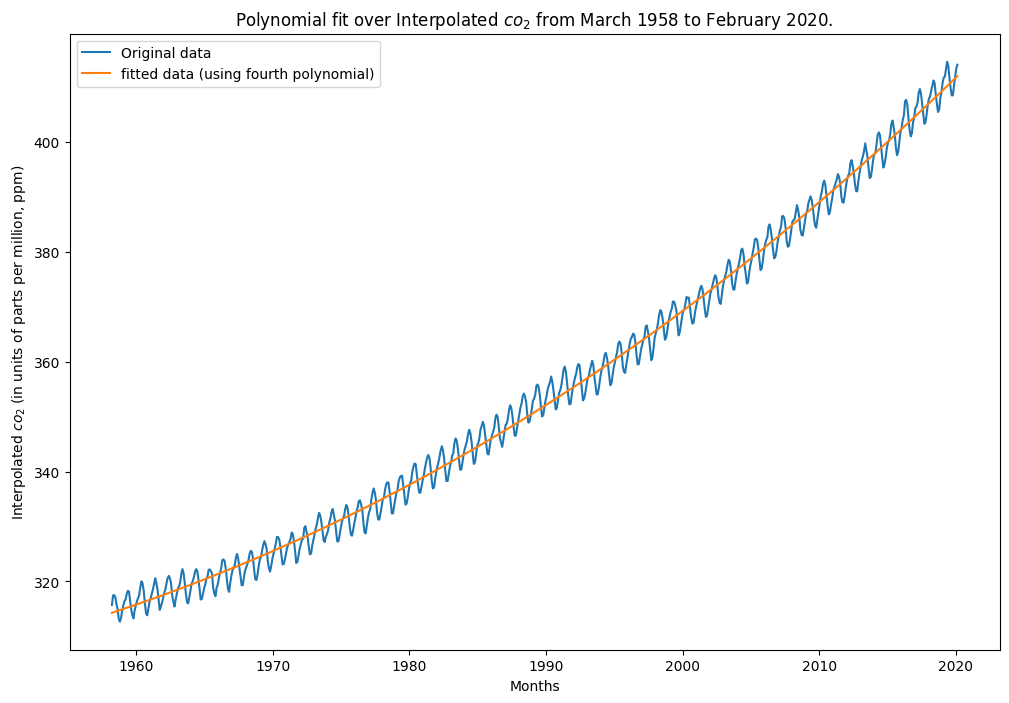

In [25]:
# Make a figure of fitted data (trend) over the original data
fig = plt.figure(figsize = (12,8))
ax1 = fig.subplots(1,1)

# Plotting the fitted data (trend) over the original data
ax1.plot(data['decimal'], data['interpolated'], label = "Original data")
ax1.plot(data['decimal'], y_fit3, label = "fitted data (using fourth polynomial)")

# Label and title
ax1.set_title(f'Polynomial fit over Interpolated $co_{2}$ from March 1958 to February 2020.')
ax1.set_ylabel(f'Interpolated $co_{2}$ (in units of parts per million, ppm)')
ax1.set_xlabel(f'Months')
ax1.legend(loc='best')


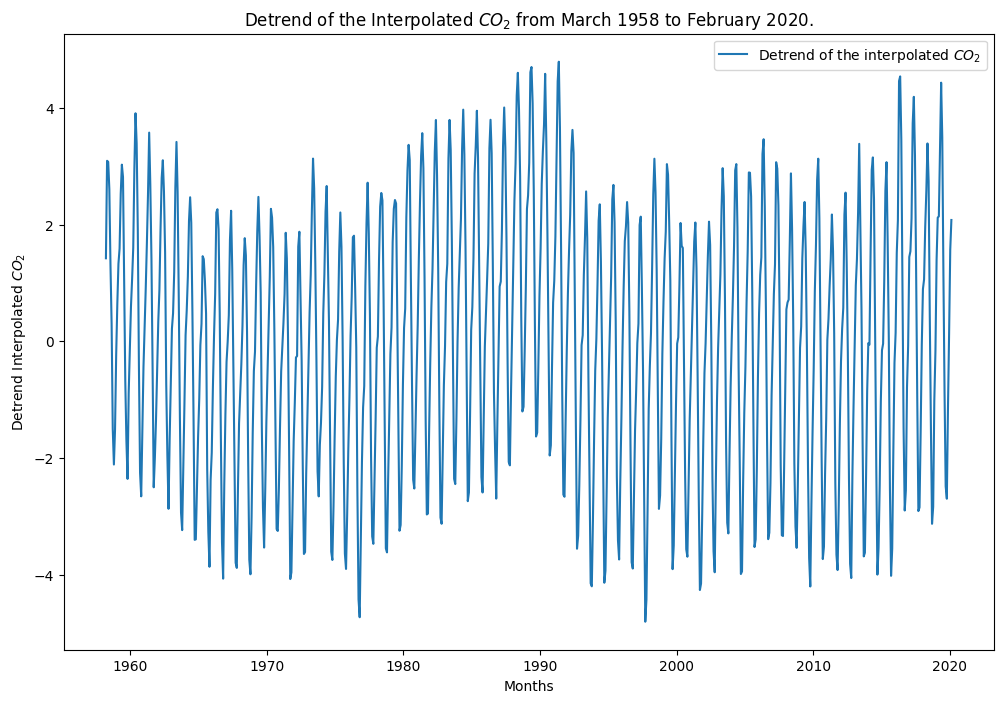

In [26]:
# Make a figure of the detrend against the data's period
fig = plt.figure(figsize = (12,8))
ax2 = fig.subplots(1,1)

# ax2.plot(data['decimal'], data['interpolated'])
ax2.plot(data['decimal'], detrend, label = f'Detrend of the interpolated $CO_{2}$')

# Label and title
ax2.set_title(f'Detrend of the Interpolated $CO_{2}$ from March 1958 to February 2020.')
ax2.set_ylabel(f'Detrend Interpolated $CO_{2}$')
ax2.set_xlabel(f'Months')
ax2.legend(loc='best')

When doing polynomial fit, one of the things that need to be considered are its order of polynomial fit.  
Choosing lower order might underfit the data while choosing higher order might overfit the data.  
The order of polynomial fit we will use here are of degree 3. We will use degree of three in our polynomial fit because the relationship between the variables, which are the interpolated $CO_{2}$ and time, are simply linear. 

After getting the detrend from the datasets, we will now use harmonic analysis and Fast Fourier Transformation (fft) on it and compare the results.

### Question 3
This section here will focus on the harmonic analysis.
To do the harmonic analysis, we will need the offset, time, frequency and amplitude.
We can get offset and time initially, but we need to calculate frequency and amplitude
along the way.

The below code are the same code from lab 3, with the difference being in the datasets used.

In [27]:
# initialize offset 
offset = detrend.mean()
# print(offset)
# initialize time vector
t = np.arange(detrend.size)
# t should be length of 804, because 67 years * 12 months
# print(len(t))

In [28]:
# Code copied from Lecture 6 demos written by Prof. Daniel Welling starts here
def coeffs(x, k=1):
    '''
    For a data vector x that is evenly spaced with no missing values,
    calculate the coefficients A and B for the k-th harmonic.

    The amplitude and phase angle are returned.
    '''
    
    # Initial values:
    A, B = 0, 0
    
    # Number of values:
    nval = x.size

    for xi, i in zip(x, range(1, nval+1)):
        A += xi*np.cos(2*np.pi*k*i/nval)
        B += xi*np.sin(2*np.pi*k*i/nval)

    A *= 2/nval
    B *= 2/nval

    # Get amplitude, phase angle:
    C = np.sqrt(A**2 + B**2)
    phi = np.arctan2(B,A)

    return C, phi

In [29]:
# Keep frequency and amplitude for each harmonic.
freqs   = np.zeros(int(detrend.size/2))
amps    = np.zeros(int(detrend.size/2))
# Create array to hold the harmonic series:
y_harmonic = np.zeros(detrend.size)

In the loop below, we will start from 1 (fundamental frequency) to half of detrend size (nyquist frequency).

In [30]:
# Loop over harmonics i=1 through npoints/2
for i in range(int(detrend.size/2)):
    # Get current frequency:
    freq = 2*np.pi*(i+1) / len(detrend)
    freqs[i] = freq

    # Get coeffs for this harmonic.
    # Note the '+1' to account for zero-based indexing in our loop.
    amp, phase = coeffs(detrend, k=i+1)
    # Store amplitude:
    amps[i] = amp
    # print(amp)
    # Sum our cosine with the rest of our harmonics:
    y_harmonic += amp * np.cos(freq * t - phase)
# Finally, add offset:
y_harmonic += offset
# print(f"Harmonic Values : {y_harmonic}")

Plotting the full harmonic over the original data. If it is similar, the harmonic analysis was considered success. The figure below are similar so the full harmonic will be considered successful.

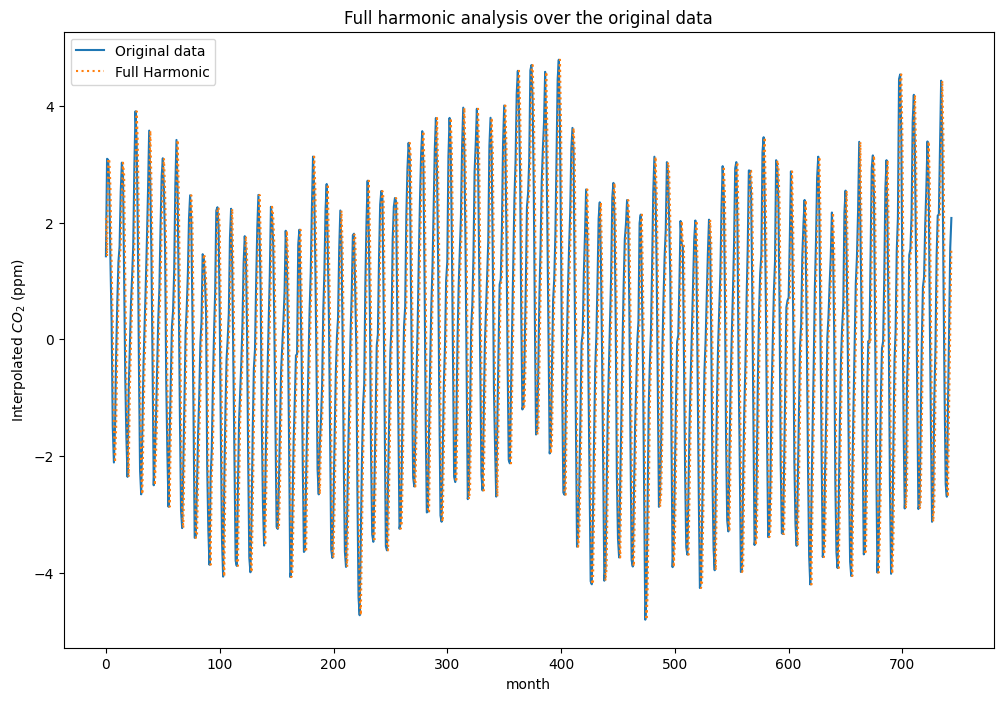

In [31]:
# Here we will plot the final full harmonic over the original data
fig = plt.figure(figsize=(12, 8))
ax1 = plt.subplot(111)


# First we plot the original dataset against the time vector
ax1.plot(t, detrend, label='Original data')
# then, we plot the final full harmonic against the time vector over the same plot above
ax1.plot(t, y_harmonic, linestyle = 'dotted', label='Full Harmonic')

# Add labels and title:
ax1.set_title(f'Full harmonic analysis over the original data')
ax1.set_ylabel(f'Interpolated $CO_{2}$ (ppm)')
ax1.set_xlabel('month')
ax1.legend(loc='best')

# Code copied from lecture 6 demos written By Prof. Daniel Welling ends

Plotting the amplitute against period

Text(0, 0.5, 'Amplitude of Interpolated $CO_2$')

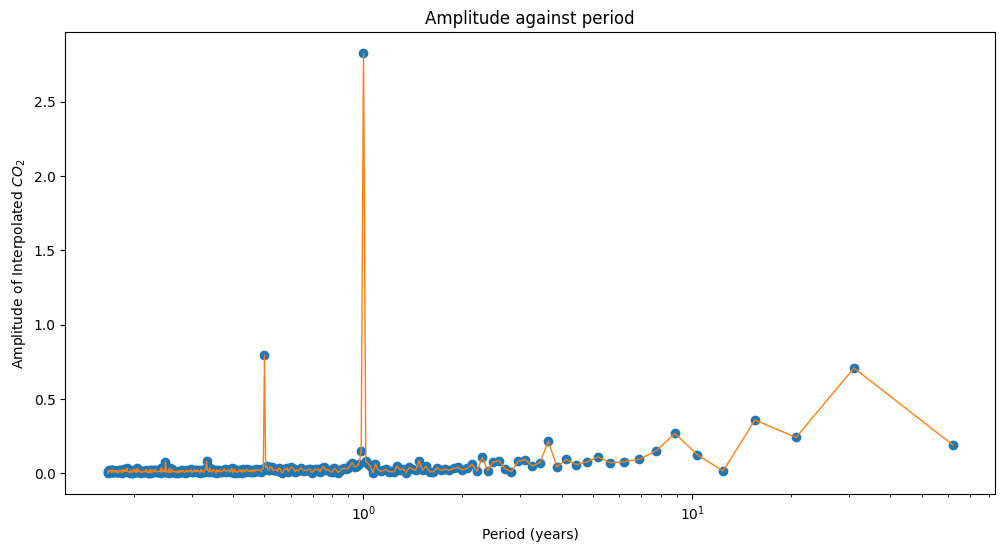

In [32]:
# Make a figure of the amplitude against period
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111)   
# change frequency to period
# the period then divided by 12 to change from months into year
freqzz = 2 * np.pi / freqs /12
ax.semilogx(freqzz, amps, 'o')
ax.semilogx(freqzz, amps, '-', lw=1)

# give title, xlabel, ylabel into axis 
ax.set_title(f'Amplitude against period')
ax.set_xlabel(f'Period (years)')
ax.set_ylabel(f'Amplitude of Interpolated $CO_{2}$')

Plotting the amplitude against frequency.

Text(0, 0.5, 'Amplitude of Interpolated $CO_2$')

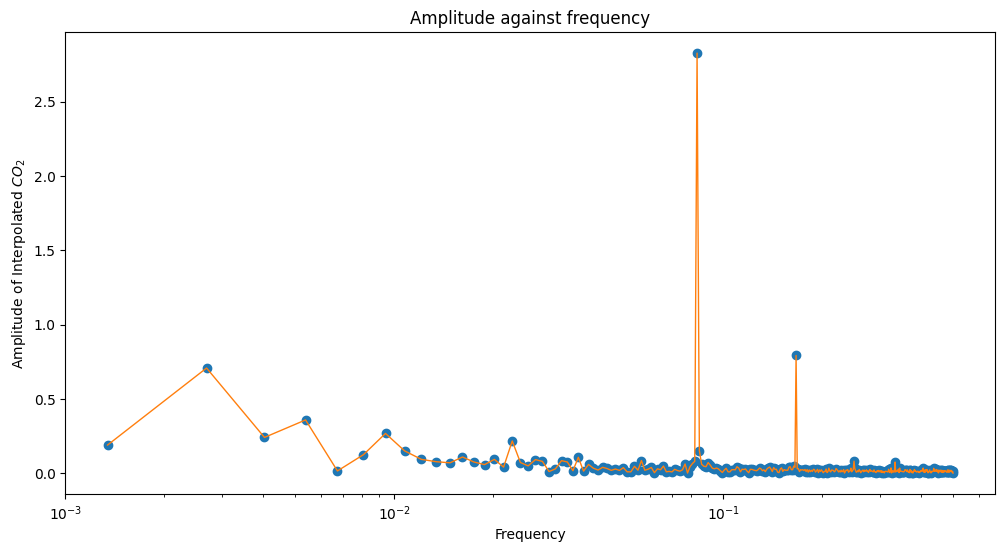

In [33]:
# Making the figure for amplitude against frequency
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111)
# from angular frequency into physical frequency
freqzz = freqs/ (2*np.pi)
ax.semilogx(freqzz, amps, 'o')
ax.semilogx(freqzz, amps, '-', lw=1)

# give title, xlabel, ylabel into axis 
ax.set_title('Amplitude against frequency')
ax.set_xlabel(f'Frequency')
ax.set_ylabel(f'Amplitude of Interpolated $CO_{2}$')

After observing the figure, we want to find the index of the largest amplitude, and from there, we will want to get the dominant frequency.

In [39]:
# The index for the largest amplitude
largest_amp_index = np.argmax(amps)
print(f"The index for the largest amplitude is : {largest_amp_index}")
freq_for_largest_amp = freqs[largest_amp_index]
print(f"The dominant angular frequency for the largest amplitude is : {freq_for_largest_amp}")
print(f"The dominant physical frequency for the largest amplitude is : {freq_for_largest_amp/(2*np.pi)}")
print(f"The dominant period for the largest amplitude is : {2 * np.pi / freq_for_largest_amp /12} year per cycle.")

The index for the largest amplitude is : 61
The dominant angular frequency for the largest amplitude is : 0.5235987755982988
The dominant physical frequency for the largest amplitude is : 0.08333333333333333
The dominant period for the largest amplitude is : 1.0 year per cycle.


The physical frequency that explain the largest fraction of interpolated $CO_{2}$ variance is 0.083Hz (for per month, not per seconds). The period that correspond to these frequency is 12.0 months per cycle.

This means that the event trend in the dataset occur annually. This makes sense, as the reason the trend happened ($CO_{2}$ concentration going low and high) was because seasonal change, for example when winter season happened at the same time annually which makes $CO_{2}$ concentration lower.

### Question 4
In this section, we will now use Fast Fourier Transformation (fft) on the detrend data.
To integrate fft on the detrend data, we will call two functions, which are fft() and fftfreq() from scipy.fftpack module.
fft() function will require the detrend data as its argument.
In other hands, fftfreq() function will need  time step (dt), and length of time series (N) as its arguments.

Below, we will call fft() and use detrend as its argument.
Then, we will minus the result with the detrend's mean.
After getting the transformation, we will want to find its frequency bins by using fftfreq() function and putting the dt and N variable we stated above as the argument.

In [41]:
from scipy.fftpack import fft, fftfreq

# monthly data, the time step is a month
dt = 1/12 
# length of time series
N = detrend.size 

# get fast fourier transform of the detrend
data_ft = fft(detrend) 

# print(detrend.mean())
# subtract the detrend mean from the transformation data
data_ft_mean = data_ft - detrend.mean()

# get frequency associated with the FT
freqsfft = fftfreq(N, dt)

[ 0.          0.01612903  0.03225806  0.0483871   0.06451613  0.08064516
  0.09677419  0.11290323  0.12903226  0.14516129  0.16129032  0.17741935
  0.19354839  0.20967742  0.22580645  0.24193548  0.25806452  0.27419355
  0.29032258  0.30645161  0.32258065  0.33870968  0.35483871  0.37096774
  0.38709677  0.40322581  0.41935484  0.43548387  0.4516129   0.46774194
  0.48387097  0.5         0.51612903  0.53225806  0.5483871   0.56451613
  0.58064516  0.59677419  0.61290323  0.62903226  0.64516129  0.66129032
  0.67741935  0.69354839  0.70967742  0.72580645  0.74193548  0.75806452
  0.77419355  0.79032258  0.80645161  0.82258065  0.83870968  0.85483871
  0.87096774  0.88709677  0.90322581  0.91935484  0.93548387  0.9516129
  0.96774194  0.98387097  1.          1.01612903  1.03225806  1.0483871
  1.06451613  1.08064516  1.09677419  1.11290323  1.12903226  1.14516129
  1.16129032  1.17741935  1.19354839  1.20967742  1.22580645  1.24193548
  1.25806452  1.27419355  1.29032258  1.30645161  1.3

Text(0, 0.5, 'Magnitude of detrend interpolated $CO_2$ after FFT transformation')

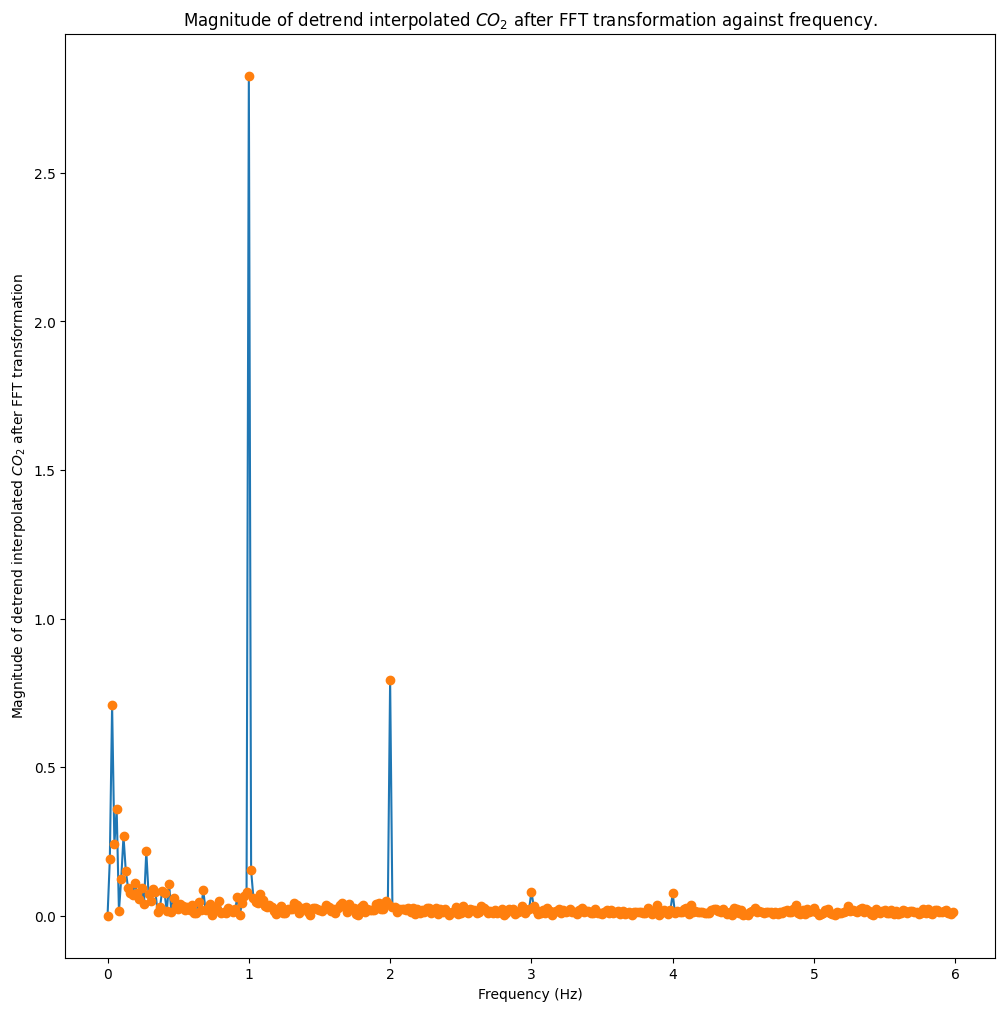

In [36]:
# Make a figure of the transformation against the frequency
fig = plt.figure(figsize=(12, 12))
axe = plt.subplot(111)

# The frequency we got from fftfreq function will have complex value (imaginary number.)
# To be more specific, the imaginary number will begin at N//2, 
# thus we will only use frequency from 0 to N//2 as it correspond to the real number.
axe.plot(freqsfft[:N//2], 2.0/N * np.abs(data_ft_mean[:N//2]))
axe.plot(freqsfft[:N//2], 2.0/N * np.abs(data_ft_mean[:N//2]), 'o')

# give title, xlabel, ylabel into axis 
axe.set_title(f'Magnitude of detrend interpolated $CO_{2}$ after FFT transformation against frequency.')
axe.set_xlabel(f'Frequency')
axe.set_ylabel(f'Magnitude of detrend interpolated $CO_{2}$ after FFT transformation')

Comparing harmonic analysis and FFT, the result from FFT was more clear to interpret than Harmonic analysis. From the FFT figure above, we can interpret that the highest magnitude in interpolated $CO_{2}$ happened
in frequency of 1, or in this context, every year. Compared to the Harmonic analysis, there will be a need to analyze the data first to get to the same calculation.
In addition, it is also easier to reach the same conclusion using FFT than Harmonic analysis. FFT takes one to two lines of code to execute, while harmonic analysis significantly needs more line of codes. 


## Conclusions
From this lab, we learn that the trend where interpolared $$CO_{2}$ has a positive linear trend every year. To reach this conclusion, we used both harmonic analysis and fft on the detrended data we got from the interporlated data. In doing so, we also found out the difference in way we understand the harmonic analysis figure and fft figure. In harmonic analysis, we will need to determine its highest amplitude and then find the corresponding frequency of that amplitude, and for better understanding, changing it to period. In other hands, in FFT analysis, we can straight away get the same conclusion as harmonic analysis without the need to process the data. This happened because FFT can calculate the Fourier transformation of the discrete signal in the Interpolated data, making it faster than harmonic analysis computational speed.


## References
List any references used